# LOAD LIBRARIES

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from diive.core.io.files import load_parquet
import os
import sys
# Custom utilities
# Add the parent directory (project root) to sys.path
# "Go up two levels" and add to path
sys.path.append(os.path.abspath('../../../')) 
from src.gapfilling_utils import (
    setup_log_transform,
    undersample_target,
    infer_cv_block_size_from_gaps,
    create_block_splits,
    plot_cv_splits,
    rfe_selection
)

# CONFIGURATION

In [13]:
START_DATE, END_DATE = '2023-10-18', '2024-08-21'
TARGET_FLUX = 'NEE'
MODEL_TYPE = 'XGBoost'  # Options: 'RandomForest' or 'XGBoost'
N_FOLDS = 10
PARCEL_CERTAIN = True # choose if to use in the training also values coming from mixed contribution
LOG_TRANSFORM = False
UNDERSAMPLE = False
ADD_ID = True
ADD_TRT = True
ADD_CANOPY = True

# LOAD DATA

In [14]:
data_main = fluxes = load_parquet(filepath=r"81.1.1_GapFillingDataset.parquet")
data_main = data_main.loc[START_DATE:END_DATE].copy()
print(f"\nUsing data from {START_DATE} to {END_DATE}")
TARGET = f"{TARGET_FLUX}_L3.3_CUT_50_QCF0"
print(f"\nTarget column: {TARGET}")

data_main

Loaded .parquet file 81.1.1_GapFillingDataset.parquet (0.134 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 

Using data from 2023-10-18 to 2024-08-21

Target column: NEE_L3.3_CUT_50_QCF0


,NEE_L3.3_CUT_16_QCF,NEE_L3.3_CUT_50_QCF,NEE_L3.3_CUT_84_QCF,NEE_L3.3_CUT_16_QCF0,NEE_L3.3_CUT_50_QCF0,NEE_L3.3_CUT_84_QCF0,parcel,parcel_certainty,trt,FC_RANDUNC_HF,SW_IN_POT,prec,ta,ppfd,sw_in,...,wfps_0.15_gfXG_diff12h,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h,n_decay_linear,n_decay_logistic,n_decay_exponential,n_decay_lognormal,n_decay_timed,timesince_fert,timesince_fert_min,timesince_fert_org,can_height,id
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-10-18 00:15:00,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,0.0,6.900000,0.0,0.0,...,0.161039,0.371742,-0.201140,-0.336475,0.617176,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,817
2023-10-18 00:45:00,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,0.0,6.866667,0.0,0.0,...,0.198957,0.473099,-0.073307,-0.363120,0.571588,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,818
2023-10-18 01:15:00,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,0.0,7.033333,0.0,0.0,...,0.196596,0.448120,-0.095540,-0.332609,0.480687,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,819
2023-10-18 01:45:00,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,0.0,7.033333,0.0,0.0,...,0.091150,0.334039,0.217531,-0.234399,0.239516,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,820
2023-10-18 02:15:00,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,0.0,7.133333,0.0,0.0,...,0.072915,0.299166,0.445909,-0.170026,0.292236,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,821
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-21 21:45:00,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,0.445311,0.0,0.0,13.353333,0.0,0.0,...,-0.957733,-1.707135,0.024579,-0.259299,-0.314632,0.0,0.0,0.0,0.0,0.0,30.0,30.0,30.0,0.0,15644
2024-08-21 22:15:00,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,0.253402,0.0,0.0,12.743333,0.0,0.0,...,-0.981586,-1.744187,0.026603,-0.248552,-0.346094,0.0,0.0,0.0,0.0,0.0,30.0,30.0,30.0,0.0,15645
2024-08-21 22:45:00,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,1.454100,0.0,0.0,12.346667,0.0,0.0,...,-0.923214,-1.720830,0.028865,-0.235925,-0.360680,0.0,0.0,0.0,0.0,0.0,30.0,30.0,30.0,0.0,15646


# CLEAN DATA

In [15]:
# Remove NAs
data = data_main[data_main[TARGET].notna()].copy()

# NEE SPECIFIC
if TARGET_FLUX == 'NEE':
    data.drop(columns='FC_RANDUNC_HF', inplace=True)
    print("\nDropped column: FC_RANDUNC_HF (NEE random uncertainty)\n")

# Remove data with mixed attribution if PARCEL_CERTAIN==True
if PARCEL_CERTAIN:
    before = len(data)
    data = data.loc[data["parcel_certainty"].eq("certain")].copy()
    print(f"Filtered parcel_certainty=='certain': {len(data)}/{before} rows kept")
else:
    print("Using all data regardless of parcel_certainty (mixed contribution allowed)")

# Remove teatment variable if ADD_TRT==False
if ADD_TRT==False:
    data.drop(columns='trt', inplace=True)
    print('\nRemoved the treatment variable (trt)')
else:
    print('\nKeeping the treatment variable (trt)')

# Remove canopy variables if ADD_CANOPY==False
if ADD_CANOPY==False:
    prefix = ('LAI', 'can_height', 'biomass', 'cropN')
    to_drop = [c for c in data.columns if c.startswith(prefix)]
    data.drop(columns=to_drop, inplace=True)
    print(f"\nDropped {len(to_drop)} canopy columns: {to_drop}")

# Drop variables related to specific parcels
to_drop = [c for c in data.columns if 'parcel' in c]
data.drop(columns=to_drop, inplace=True)
print(f"\nDropped {len(to_drop)} parcel-specific columns: {to_drop}")

# keep numeric only (feature selection models require numeric)
data = data.select_dtypes(include=[np.number]).copy()

# Remove any flux variable with TARGET_FLUX except for the target itself
to_drop = [c for c in data.columns if (TARGET_FLUX in c and c != TARGET)]
data.drop(columns=to_drop, inplace=True)

# Remove feature columns with too many missing values where target is not missing
drop_missing = [
    c for c in data.columns
    if c != TARGET and data[c].isna().mean() > 0.05
]
data.drop(columns=drop_missing, inplace=True)
print(f"Dropped {len(drop_missing)} high-missing features (>5% NA) where target is not missing: {drop_missing}")

# Build complete-case training set
feature_cols = [c for c in data.columns if c != TARGET]
train_mask = data[TARGET].notna() & data[feature_cols].notna().all(axis=1)
df_train = data.loc[train_mask, feature_cols + [TARGET]].copy()
print(f"Training rows (complete-case): {len(df_train)}/{len(data)}")

X = df_train[feature_cols]
y = df_train[TARGET].astype(float)

df_train


Dropped column: FC_RANDUNC_HF (NEE random uncertainty)

Filtered parcel_certainty=='certain': 5703/6552 rows kept

Keeping the treatment variable (trt)

Dropped 20 parcel-specific columns: ['parcel', 'parcel_certainty', 'n_decay_linear_parcelA', 'n_decay_linear_parcelB', 'n_decay_logistic_parcelA', 'n_decay_logistic_parcelB', 'n_decay_exponential_parcelA', 'n_decay_exponential_parcelB', 'n_decay_lognormal_parcelA', 'n_decay_lognormal_parcelB', 'n_decay_timed_parcelA', 'n_decay_timed_parcelB', 'timesince_fert_parcelA', 'timesince_fert_parcelB', 'timesince_fert_min_parcelA', 'timesince_fert_min_parcelB', 'timesince_fert_org_parcelA', 'timesince_fert_org_parcelB', 'can_height_parcelA', 'can_height_parcelB']
Dropped 0 high-missing features (>5% NA) where target is not missing: []
Training rows (complete-case): 5703/5703


,trt,SW_IN_POT,prec,ta,ppfd,sw_in,rh,timesince_prec,vpd,ts_0.05_gfXG,ts_0.15_gfXG,ts_0.3_gfXG,wfps_0.05_gfXG,wfps_0.15_gfXG,wfps_0.3_gfXG,...,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h,n_decay_linear,n_decay_logistic,n_decay_exponential,n_decay_lognormal,n_decay_timed,timesince_fert,timesince_fert_min,timesince_fert_org,can_height,id,NEE_L3.3_CUT_50_QCF0
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-22 11:15:00,0.0,508.623,0.238,3.166667,100.485834,49.333333,95.516667,0,0.034392,4.214833,6.794001,7.766860,50.003806,56.279186,46.719290,...,1.199013,0.861383,1.659645,2.910261,0.0,0.0,0.0,0.0,0.0,30.0,30.0,30.0,0.592505,2519,0.870527
2023-11-22 11:45:00,0.0,531.452,0.000,3.043333,78.235791,38.666667,95.280000,1,0.035892,3.948499,6.777297,7.739503,49.749778,56.502881,45.122243,...,1.485885,-0.853927,-1.348990,1.416971,0.0,0.0,0.0,0.0,0.0,30.0,30.0,30.0,0.593197,2520,0.844507
2023-11-22 12:15:00,0.0,539.106,0.000,3.056667,82.407674,40.666667,94.870000,2,0.039047,3.508604,6.869158,7.751822,50.231189,56.340153,44.602581,...,1.168242,-1.600306,-1.980507,0.359746,0.0,0.0,0.0,0.0,0.0,30.0,30.0,30.0,0.593890,2521,0.629330
2023-11-22 12:45:00,0.0,531.452,0.000,3.000000,98.399892,48.333333,93.753333,3,0.047355,3.253336,6.856443,7.714983,49.543728,56.270616,44.413254,...,1.077855,-1.631950,-1.463329,-0.060023,0.0,0.0,0.0,0.0,0.0,30.0,30.0,30.0,0.594582,2522,0.602554
2023-11-22 13:15:00,0.0,508.623,0.000,2.946667,117.173366,57.333333,93.543333,4,0.048761,3.404743,6.836869,7.638218,49.836477,56.365712,44.046013,...,1.167029,-3.529501,-1.774765,-0.246205,0.0,0.0,0.0,0.0,0.0,30.0,30.0,30.0,0.595275,2523,0.477717
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-21 07:45:00,1.0,546.133,0.000,18.866667,388.308602,200.752348,78.923334,99,0.460022,19.089631,20.300000,20.185557,32.804274,45.907559,42.866541,...,-1.528764,-0.039938,0.015491,-0.164574,0.0,0.0,0.0,0.0,0.0,30.0,30.0,30.0,0.000000,15616,1.885274
2024-08-21 08:15:00,1.0,650.152,0.000,18.730000,277.587545,143.583468,78.430000,100,0.466785,19.149260,20.242222,20.122222,32.743272,45.858821,42.842657,...,-1.522234,-0.066068,-0.031802,-0.178905,0.0,0.0,0.0,0.0,0.0,30.0,30.0,30.0,0.000000,15617,2.572873
2024-08-21 13:45:00,1.0,1025.990,0.000,20.496667,1373.467598,680.736891,59.940000,111,0.967445,22.009258,20.529630,19.909629,31.188045,45.364764,42.633439,...,-1.612833,-0.233102,-0.273040,-0.280486,0.0,0.0,0.0,0.0,0.0,30.0,30.0,30.0,0.000000,15628,-0.758393


# IMBALANCE HANDLING

## UNDER SAMPLING

In [16]:
if UNDERSAMPLE:
    df_train2, cutoff_value = undersample_target(
        df_train, TARGET,
        quantile_cutoff=0.7,
        fraction=0.5,
        random_state=42,
        verbose=True,
    )
    df_train = df_train2
    X = df_train.drop(columns=[TARGET])
    y = df_train[TARGET].astype(float)
else:
    print("Undersampling not applied.")

Undersampling not applied.


## LOG TRANSFORMATION

In [17]:
if LOG_TRANSFORM:
    log_fn, inv_fn, min_value, df_train2 = setup_log_transform(
        df_train, TARGET, apply=True, plot=True, bins=20
    )
    df_train = df_train2
    X = df_train.drop(columns=[TARGET])
    y = df_train[TARGET].astype(float)
    print(f"Applied log1p transform (shift={min_value if min_value < 0 else 0.0:.4g}).")
else:
    inv_fn = None
    print("Log transform not applied.")


Log transform not applied.


# CROSS-VAL SPLITS


Using block size of 7 time steps for CV splits.

Requested split=0.10; n_folds=10; achieved test fractions ~ 0.099–0.101


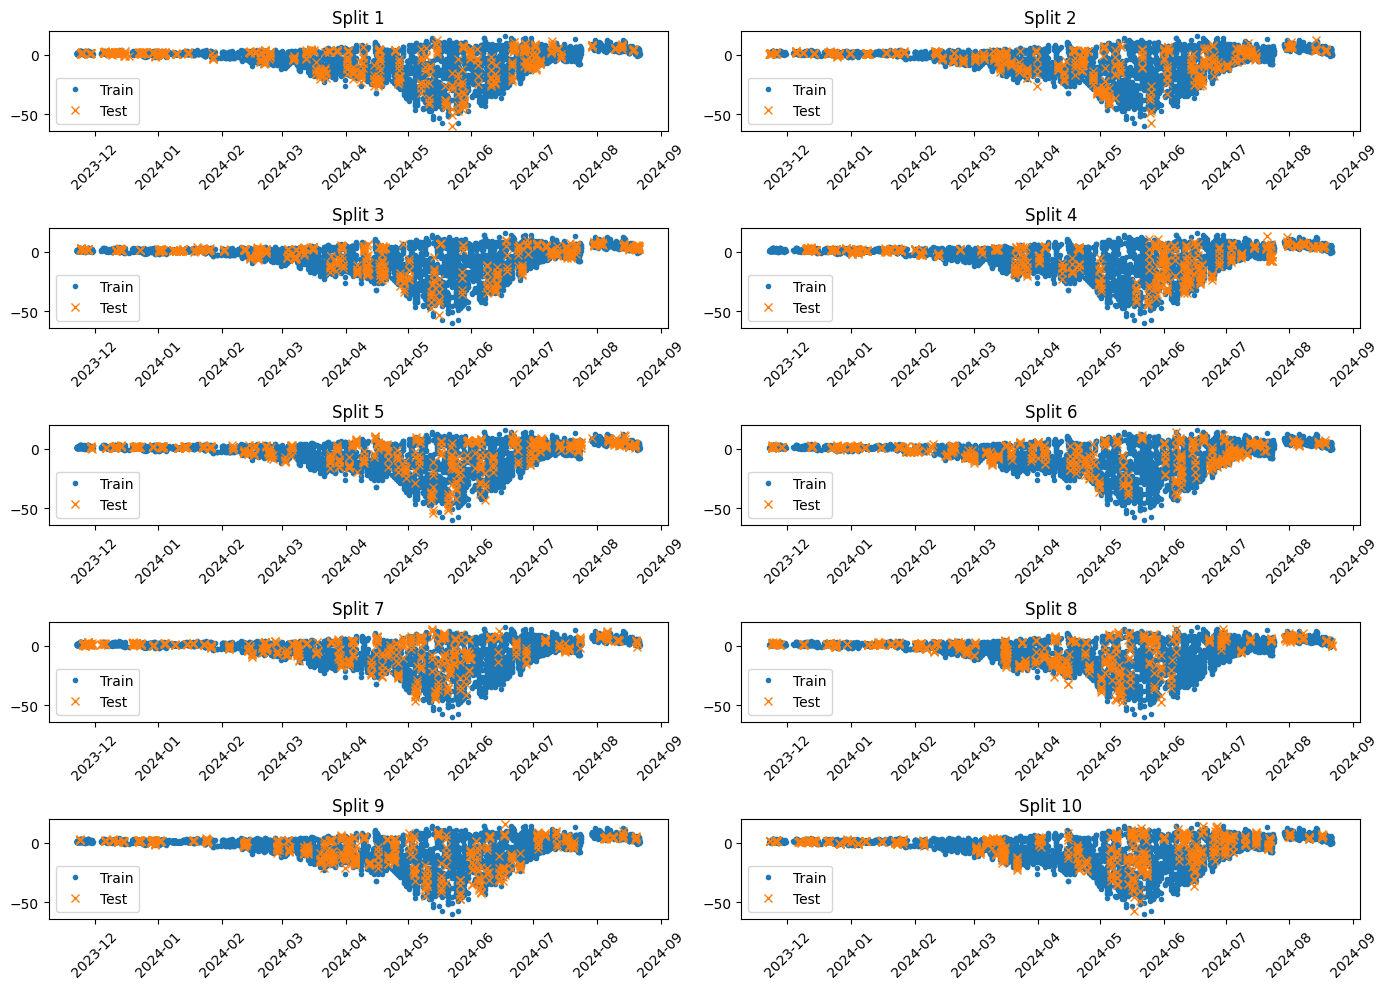

In [18]:
# Time-block cross-validation splits
# Block size is inferred from gaps in the target variable
block_size = infer_cv_block_size_from_gaps(data_main[TARGET], quantile=0.9, fallback=6)
print(f"\nUsing block size of {block_size} time steps for CV splits.\n")
split_frac = 1.0 / float(N_FOLDS)
splits = create_block_splits(
    X,
    split=split_frac,
    block_size=block_size,
    random_state=42,
    shuffle_blocks=True,
    verbose=True,
)

# optional diagnostic plot
plot_cv_splits(X, y, splits, ncols=2);


# FEATURE SELECTION

In [19]:
# Model factory
def model_factory():
    if MODEL_TYPE == "RandomForest":
        return RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
        )
    elif MODEL_TYPE == "XGBoost":
        return XGBRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
        )
    else:
        raise ValueError("MODEL_TYPE must be 'RandomForest' or 'XGBoost'")

model_factory()

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=-1, num_parallel_tree=None, ...)

Iter 1: kept=157 removed=['timesince_fert_min', 'timesince_fert_org', 'prec', 'prec_lag9h', 'trt', 'prec_lag6h_roll3hsum', 'prec_lag6h', 'wfps_0.15_gfXG_lag9h_roll3hmean', 'wfps_0.05_gfXG_diff6h', 'wfps_0.05_gfXG_diff12h'] RMSE_oof=2.0471 R2_oof=0.9661
Iter 2: kept=147 removed=['timesince_sowing', 'ta', 'prec_lag9h_roll6hsum', 'wfps_0.05_gfXG_roll6hmean', 'prec_lag3h_roll6hsum', 'wfps_0.05_gfXG_lag6h_roll9hmean', 'wfps_0.05_gfXG', 'wfps_0.15_gfXG_roll3hmean', 'prec_roll9hsum', 'wfps_0.15_gfXG_lag6h'] RMSE_oof=2.0326 R2_oof=0.9666
Iter 3: kept=137 removed=['wfps_0.15_gfXG_lag6h_roll9hmean', 'wfps_0.05_gfXG_lag3h_roll6hmean', 'wfps_0.05_gfXG_lag6h', 'wfps_0.3_gfXG_diff6h', 'ts_0.05_gfXG', 'wfps_0.15_gfXG_lag3h', 'prec_lag3h', 'wfps_0.15_gfXG_diff6h', 'prec_lag6h_roll9hsum', 'ts_0.15_gfXG_diff12h'] RMSE_oof=2.0259 R2_oof=0.9668
Iter 4: kept=127 removed=['wfps_0.15_gfXG_lag9h', 'wfps_0.05_gfXG_lag9h_roll3hmean', 'ts_0.3_gfXG_lag3h_roll6hmean', 'wfps_0.3_gfXG_lag3h', 'ta_lag6h', 'wfps_0.15_

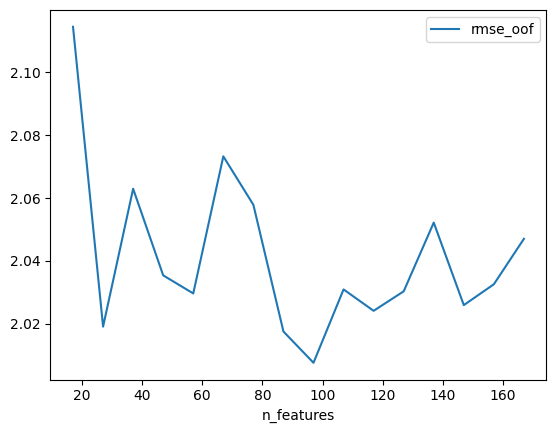

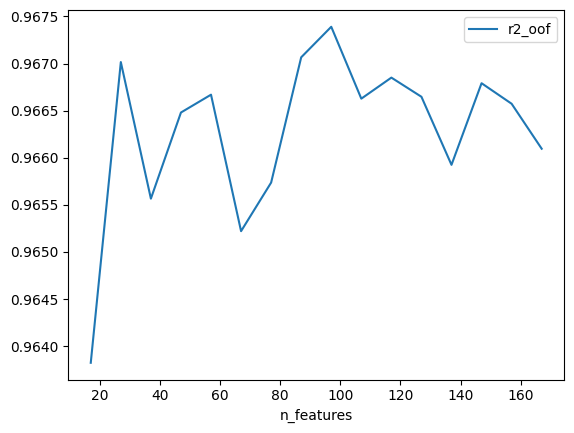

In [20]:
best_feats, ranking, hist = rfe_selection(
    X, y, splits,
    model_factory=model_factory,
    inv_y=inv_fn if LOG_TRANSFORM else None,
    step=10,           # try 5 or 10 if it’s slow
    min_features=10,   
    verbose=True,
    score_mode='composite',  # 'rmse' or 'composite',
    w_penalty = 0.001
)

# optional plot in notebook
hist.plot(x="n_features", y="rmse_oof");
hist.plot(x="n_features", y="r2_oof");

print(f"\nBest features selected:\n{best_feats}")
print(f"\nFeature ranking:\n{ranking}")


# EXPORT 

In [21]:
filename = f"best_features_{TARGET_FLUX}_{MODEL_TYPE}.txt"
with open(filename, "w") as f:
    for item in best_feats:
        f.write(f"{item}\n")
print("Wrote:", filename)

filename = f"ranked_features_{TARGET_FLUX}_{MODEL_TYPE}.txt"
with open(filename, "w") as f:
    for item in ranking:
        f.write(f"{item}\n")
print("Wrote:", filename)


Wrote: best_features_NEE_XGBoost.txt
Wrote: ranked_features_NEE_XGBoost.txt


# **End of notebook**

In [22]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished {dt_string}")

Finished 2026-02-11 11:46:53
